# Aula 05 — Human-in-the-Loop (HITL) com LangGraph

## Visão Geral

Este notebook demonstra o padrão **Human-in-the-Loop (HITL)** com LangGraph: a capacidade de **pausar** a execução do grafo em pontos estratégicos para que um humano possa inspecionar, aprovar, rejeitar ou modificar o que o agente está prestes a fazer antes de continuar.

### Conceitos Principais

| Conceito | Descrição |
|---|---|
| `interrupt_before` | Parâmetro de `compile()` que pausa o grafo ANTES de nós específicos |
| `graph.stream(None, config)` | Retoma a execução a partir do ponto de pausa |
| `graph.get_state(config)` | Inspeciona o estado atual do grafo (snapshot) |
| `graph.update_state(config, values)` | Injeta valores no estado antes de continuar |
| `reduce_messages` | Reducer customizado que faz UPSERT por ID (em vez de append puro) |

### Fluxo HITL

```
[entrada]
    |
    v
[nó: llm]  →  tem tool_call?
                    |
              NÃO --+-- SIM
              |           |
             END      [PAUSA] ← interrupt_before=["action"]
                          |
                   humano inspeciona
                   get_state() / update_state()
                          |
               aprova? ---+--- rejeita / modifica
                  |                  |
            stream(None)         estado alterado
                  |                  |
           [nó: action]           END (sem executar ferramenta)
                  |
           [nó: llm] → ...
```


## 1. Instalação das Dependências

Instala todas as bibliotecas necessárias para o notebook:

| Pacote | Finalidade |
|---|---|
| `langchain`, `langchain-google-genai` | Framework base + integração com Gemini |
| `langchain_community`, `tavily-python`, `langchain-tavily` | Ferramenta de busca Tavily |
| `aiosqlite` | Suporte assíncrono para SQLite |
| `langgraph-checkpoint-sqlite` | Backend de persistência SQLite para checkpoints |
| `langgraph` | Framework de grafos para agentes com estado |


In [7]:
%pip install langchain langchain-google-genai langchain_community tavily-python aiosqlite langchain-tavily 
%pip install langgraph-checkpoint-sqlite 
%pip install langgraph langgraph-checkpoint-sqlite
%pip install langgraph 

  Using cached google_ai_generativelanguage-0.6.18-py3-none-any.whl.metadata (9.8 kB)
Using cached google_ai_generativelanguage-0.6.18-py3-none-any.whl (1.4 MB)
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.15
    Uninstalling google-ai-generativelanguage-0.6.15:
      Successfully uninstalled google-ai-generativelanguage-0.6.15
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.18 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 2. Imports e Configuração de Persistência

Importa os módulos principais e configura o **checkpointer SQLite**, que é responsável por salvar e restaurar o estado do grafo entre execuções — condição necessária para que o HITL funcione.

### Por que `check_same_thread=False`?

Por padrão, o SQLite lança um erro se a conexão for acessada de uma thread diferente da que a criou. Em notebooks Jupyter, o event loop e o código podem rodar em threads diferentes, por isso desabilitamos essa restrição.

### `SqliteSaver`

O `SqliteSaver` implementa a interface de checkpointer do LangGraph, persistindo cada snapshot de estado em uma tabela SQLite. Isso permite:
- Retomar execuções pausadas (`stream(None, config)`)
- Inspecionar o estado em qualquer ponto (`get_state(config)`)
- Modificar o estado antes de continuar (`update_state(config, values)`)


In [8]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Any, Dict
import operator
from typing_extensions import TypedDict
# AnyMessage é uma union type de todas as classes de mensagem do LangChain
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# check_same_thread=False permite que o SQLite seja acessado de múltiplas
# threads — necessário em notebooks Jupyter onde o event loop pode ser
# executado em thread diferente do código principal
conn = sqlite3.connect("checkpoints.db", check_same_thread=False)

# SqliteSaver implementa a interface de checkpointer do LangGraph,
# persistindo snapshots de estado no banco SQLite local
memory = SqliteSaver(conn)

from dataclasses import dataclass, field

## 3. Configuração de Variáveis de Ambiente

Carrega as chaves de API do arquivo `.env` e as exporta como variáveis de ambiente para uso pelas bibliotecas LangChain/Google.

> **Nota:** A chave do Gemini é lida como `GEMINI_API_KEY` no `.env` e reatribuída a `GOOGLE_API_KEY`, que é o nome esperado pela biblioteca `langchain-google-genai`.


In [9]:
import google.generativeai as genai
from dotenv import load_dotenv

# Carrega variáveis do arquivo .env para o ambiente
load_dotenv()

# A biblioteca langchain-google-genai usa GOOGLE_API_KEY,
# mas guardamos a chave no .env como GEMINI_API_KEY — fazemos o mapeamento aqui
os.environ['GOOGLE_API_KEY'] = os.getenv('GEMINI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

## 4. Esquemas de Estado do Agente

Define o `AgentState` — o schema TypedDict que representa o estado compartilhado entre todos os nós do grafo.

### `operator.add` vs `reduce_messages`

| Reducer | Comportamento | Problema |
|---|---|---|
| `operator.add` | Concatena (append) mensagens novas à lista existente | Duplica mensagens se a mesma for enviada duas vezes |
| `reduce_messages` | Faz **UPSERT por ID**: atualiza se já existe, adiciona se não existe | Correto para HITL onde mensagens podem ser substituídas |

> A célula abaixo é apenas um **exemplo ilustrativo** com `operator.add`. O reducer real usado no agente é definido na próxima célula.


In [ ]:
# EXEMPLO APENAS — não é o estado final usado no agente.
# Usa operator.add como reducer: cada update CONCATENA novas mensagens.
# Problema: se a mesma mensagem for enviada duas vezes (ex: no HITL),
# ela será duplicada no histórico.

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

### Reducer Customizado: `reduce_messages`

Implementa a estratégia de **UPSERT (Update or Insert)** para a lista de mensagens:

```
Para cada mensagem em 'right' (novas):
  ├─ Garante que a mensagem tenha um ID único (uuid4)
  └─ Busca na lista 'left' (existentes):
       ├─ ID já existe → SUBSTITUI (update)
       └─ ID não existe → ADICIONA ao final (insert)
```

Isso é fundamental para o HITL porque quando usamos `update_state()`, precisamos que a mensagem substituída **sobrescreva** a original no histórico, e não crie uma cópia duplicada.

O `AgentState` final usa `reduce_messages` como reducer da lista de mensagens.


In [10]:
from uuid import uuid4

def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    """
    Reducer customizado que faz UPSERT das mensagens por ID.

    - Se uma mensagem em 'right' já existe em 'left' (mesmo ID) → SUBSTITUI
    - Se não existe → ADICIONA ao final

    Isso é essencial para o HITL: quando injetamos uma mensagem via update_state(),
    precisamos substituir a AIMessage original (com tool_calls) pela nova (sem tool_calls),
    evitando duplicatas no histórico.
    """
    # Garante que todas as mensagens novas tenham um ID único
    for message in right:
        if not message.id:
            message.id = str(uuid4())

    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            # Se o ID já existe na lista, substitui a mensagem (UPDATE)
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            # ID não encontrado: adiciona ao final da lista (INSERT)
            merged.append(message)
    return merged


# Estado final do agente: usa reduce_messages para suportar HITL corretamente
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

## 5. Instalação de Dependências Adicionais

Reinstala/confirma pacotes necessários para a ferramenta de busca e para a integração com o Google Generative AI.


In [11]:
%pip install langchain-community tavily-python
%pip install google-generativeai

Note: you may need to restart the kernel to use updated packages.


  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl (1.3 MB)
  Attempting uninstall: google-ai-generativelanguage
    Found existing installation: google-ai-generativelanguage 0.6.18
    Uninstalling google-ai-generativelanguage-0.6.18:
      Successfully uninstalled google-ai-generativelanguage-0.6.18
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-google-genai 2.1.9 requires google-ai-generativelanguage<0.7.0,>=0.6.18, but you have google-ai-generativelanguage 0.6.15 which is incompatible.


## 6. Ferramenta de Busca

Instancia o `TavilySearchResults`, a ferramenta de busca em tempo real que o agente poderá chamar. O parâmetro `max_results=2` limita o número de resultados retornados por consulta, reduzindo o consumo de tokens.


In [12]:
# Instancia a ferramenta de busca Tavily com limite de 2 resultados por consulta.
# max_results=2 é um balanço entre contexto relevante e custo de tokens.
tool = TavilySearchResults(max_results=2)

## 7. Classe `Agent` com `interrupt_before`

Define a classe `Agent` que encapsula o grafo LangGraph com suporte a HITL.

### Detalhe Crítico: `interrupt_before=["action"]`

```python
self.graph = graph.compile(
    checkpointer=checkpointer,
    interrupt_before=["action"]  # <-- pausa ANTES do nó 'action'
)
```

Esse parâmetro instrui o LangGraph a **pausar automaticamente** toda vez que o fluxo estiver prestes a entrar no nó `"action"`. A execução fica suspensa no checkpoint e só retoma quando `stream(None, config)` for chamado.

### Estrutura do Grafo

```
ENTRY → [llm] → exists_action? → True  → [PAUSA] → [action] → [llm] → ...
                                → False → END
```

| Método | Responsabilidade |
|---|---|
| `call_gemini` | Invoca o LLM com o histórico de mensagens |
| `exists_action` | Verifica se a última mensagem contém tool_calls |
| `take_action` | Executa as ferramentas solicitadas e retorna ToolMessages |


In [ ]:
from langgraph.graph import StateGraph, END
from langchain_core.messages import SystemMessage, ToolMessage
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage

class Agent:

    def __init__(self, model, tools, system="", checkpointer=None):
        self.system = system

        # Monta o grafo de estados com dois nós principais: llm e action
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)

        # Aresta condicional: após o LLM, verifica se há tool_calls pendentes
        # True → vai para 'action' | False → encerra (END)
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})

        # Após executar a ação, sempre volta ao LLM para processar o resultado
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")

        self.graph = graph.compile(
            checkpointer=checkpointer,
            # PONTO CENTRAL DO HITL: pausa o grafo ANTES de entrar no nó "action",
            # dando ao humano a oportunidade de inspecionar, aprovar ou cancelar
            # a chamada de ferramenta que o LLM decidiu fazer.
            interrupt_before=["action"]
        )
        # Mapeia nome → instância de cada ferramenta para lookup rápido
        self.tools = {t.name: t for t in tools}
        # Vincula as ferramentas ao modelo para que ele saiba como chamá-las
        self.model = model.bind_tools(tools)

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        # Injeta a mensagem de sistema no início do histórico (não é armazenada no estado)
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def exists_action(self, state: AgentState):
        print(state)
        result = state['messages'][-1]
        # Retorna True se a última mensagem do LLM contém chamadas de ferramenta
        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Chamando ferramenta: {t['name']} com argumentos: {t['args']}")
            # Executa a ferramenta e empacota o resultado como ToolMessage
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Voltando para o modelo!")
        return {'messages': results}

## 8. Instanciando o Agente com Checkpointer

Cria a instância do agente passando:
- O modelo Gemini 1.5 Pro
- A ferramenta de busca Tavily
- Um prompt de sistema com instruções para busca em tempo real
- O `memory` (SqliteSaver) como checkpointer

O prompt inclui a data atual dinamicamente para que o agente sempre inclua a data nas consultas de busca, garantindo resultados mais recentes.


In [14]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y")

# Prompt dinâmico: inclui a data atual para que o agente sempre use
# a data correta nas consultas de busca, evitando resultados desatualizados
prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGoogleGenerativeAI(model="gemini-1.5-pro")

# Passa o checkpointer 'memory' (SqliteSaver) para habilitar:
# 1. Persistência de estado entre execuções
# 2. Suporte ao interrupt_before (necessário para HITL)
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

## 9. Gerando Thread IDs Únicos

Cada conversa com o agente precisa de um **thread ID único** para que o checkpointer possa separar os históricos de estado de conversas diferentes.

### Por que `uuid4()`?

O `uuid4()` gera um identificador aleatório de 128 bits com probabilidade de colisão astronomicamente baixa (~1 em 5,3 × 10³⁶), sendo a escolha padrão para IDs de sessão sem necessidade de coordenação centralizada.

O thread ID é passado em:
```python
thread_config = {"configurable": {"thread_id": session_id}}
```


In [16]:
import uuid

# Gera um ID de sessão único para esta conversa.
# Cada thread_id isolado no checkpointer representa uma conversa independente,
# com seu próprio histórico de mensagens e estado do grafo.
dynamic_thread_id = str(uuid.uuid4())

print(f"Meu novo Thread ID dinâmico é: {dynamic_thread_id}")

Meu novo Thread ID dinâmico é: f6a46d70-2ae6-49e0-b53c-c8f21a6d9d38


## 10. Demonstração HITL — Aprovação Humana

Demonstra o fluxo completo de Human-in-the-Loop com interação via `input()`:

```
Etapa 1: stream({messages: [pergunta]}, config)
              |
         [nó: llm] → decide chamar ferramenta
              |
         [PAUSA automática] ← interrupt_before=["action"]
              |
         get_state(config) → inspeciona tool_calls pendentes
              |
         input("Aprovar? sim/não")
              |
         SIM → Etapa 2: stream(None, config) → retoma execução
              |              |
              |         [nó: action] → executa ferramenta
              |              |
              |         [nó: llm] → gera resposta final
              |
         NÃO → encerra sem executar a ferramenta
```

### Pontos de Atenção

| Chamada | Significado |
|---|---|
| `stream({messages: [...]}, config)` | Inicia nova execução a partir de uma mensagem |
| `stream(None, config)` | Retoma execução pausada (sem nova entrada) |
| `get_state(config).next` | Indica qual nó está aguardando execução (`('action',)` = pausado antes de action) |


In [20]:
session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando nova conversa com ID: {session_id}\n")

user_message = "Como está o tempo em São Paulo hoje?"
messages = [HumanMessage(content=user_message)]

# O thread_config vincula esta execução à thread de checkpoint específica.
# Todas as operações (stream, get_state, update_state) que usam este config
# operam sobre o mesmo histórico de estado isolado.
thread_config = {"configurable": {"thread_id": session_id}}

print("--- Etapa 1: Agente processa a entrada e decide a ação ---")
print(f"Você: {user_message}")

# ETAPA 1: Inicia o stream. O grafo executará o nó 'llm' e PAUSARÁ
# automaticamente antes de 'action' (por causa do interrupt_before).
for event in abot.graph.stream({"messages": messages}, thread_config):

    for k, v in event.items():
        if k == "llm":
            last_message = v.get('messages', [])[-1]
            if isinstance(last_message, AIMessage) and last_message.tool_calls:
                print(f"\nAgente (decisão): {last_message.tool_calls}")
                print("\n--- AGENTE PAUSADO: Intervenção Humana Necessária ---")
            else:
                print(f"\nAgente (resposta direta/sem tool_calls): {last_message.content}")
                print("\n--- AGENTE PAUSADO (resposta direta, sem ação pendente) ---")

# Inspeciona o estado atual para descobrir o que está pendente
current_state = abot.graph.get_state(thread_config)

last_state_message = current_state.values['messages'][-1]

# Verifica se o grafo está pausado ANTES do nó 'action' com tool_calls pendentes
if current_state and current_state.next == ('action',) and isinstance(last_state_message, AIMessage) and last_state_message.tool_calls:
    tool_calls_pending = last_state_message.tool_calls
    if tool_calls_pending:
        print("\nO agente decidiu executar a(s) seguinte(s) ação(ões) de ferramenta:")
        for tc in tool_calls_pending:
            print(f"- Ferramenta: {tc['name']}, Argumentos: {tc['args']}")

        # PONTO DE DECISÃO HUMANA: o usuário decide se aprova ou não a ação
        user_input = input("\nVocê deseja que o agente execute esta(s) ação(ões)? (sim/não): ").lower()

        if user_input == 'sim':

            # ETAPA 2: Retoma a execução passando None como input.
            # O grafo continua do ponto de pausa (antes de 'action').
            print("\n--- Etapa 2: Retomando a execução (Agente executará a ação) ---")
            for event in abot.graph.stream(None, thread_config):
                for k, v in event.items():
                    if k == "action":
                        print(f"DEBUG: Ferramenta executada e resultado retornado: {v}")
                    elif k == "llm":
                        final_response_message = v.get('messages', [])[-1].content
                        print(f"\nAgente (resposta final): {final_response_message}")
                    elif k == END:
                        print(f"DEBUG: Grafo terminou a execução.")
            print("\n--- FIM DA INTERAÇÃO ---")
        else:
            # Usuário cancelou: o estado pausado continua salvo no SQLite,
            # mas não retomamos o stream — a ação nunca é executada.
            print("\nExecução da ação cancelada pelo usuário.")
            print("--- FIM DA INTERAÇÃO ---")
    else:
        print("\nO agente não decidiu nenhuma ação de ferramenta apesar da pausa. Interação encerrada.")
else:
    # O LLM respondeu diretamente sem precisar de ferramenta
    print("\nO agente respondeu diretamente ou não pausou em uma ação. Não há ações pendentes para aprovar.")
    if current_state:
        final_response_message = current_state.values['messages'][-1].content
        print(f"Agente (resposta direta): {final_response_message}")
    print("--- FIM DA INTERAÇÃO ---")

DEBUG: Iniciando nova conversa com ID: 52dc3d1a-74da-422a-8197-c872969deed0

--- Etapa 1: Agente processa a entrada e decide a ação ---
Você: Como está o tempo em São Paulo hoje?
{'messages': [HumanMessage(content='Como está o tempo em São Paulo hoje?', additional_kwargs={}, response_metadata={}, id='5305a2b0-1553-4ff3-9f73-26e30269b8b4'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 20/08/2025"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-pro-002', 'safety_ratings': []}, id='run--d3f2b651-6332-4bc3-bb13-913ecdfa029d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'tempo em São Paulo 20/08/2025'}, 'id': 'd8212e45-e849-4753-9bd0-cc62c0edf66c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 296, 'output_tokens': 24, 'total_tokens': 320, 'input_token_details': {'cac

## 11. Visualizando o Grafo com `interrupt_before`

Renderiza uma representação visual do grafo compilado. O diagrama mostrará o nó `action` com a marcação de ponto de interrupção, evidenciando onde o HITL ocorre no fluxo.

Tenta gerar como PNG (via Mermaid); se não disponível, imprime o código Mermaid para visualização em https://mermaid.live/.



--- Tentando Gerar PNG do Grafo via Mermaid ---


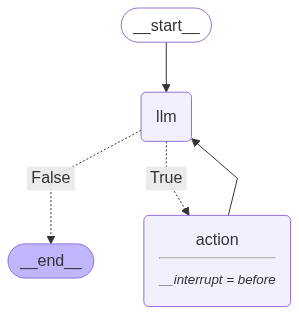

In [21]:
from IPython.display import Image, display

print("\n--- Tentando Gerar PNG do Grafo via Mermaid ---")
try:
    # draw_mermaid_png() gera uma imagem PNG do grafo usando a API Mermaid.
    # O grafo compilado com interrupt_before exibirá o ponto de interrupção visualmente.
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except AttributeError:
    print("Método `.draw_mermaid_png()` não encontrado ou não suportado.")
    print("Tentando gerar apenas o código Mermaid...")
    try:
        # Fallback: gera o código Mermaid para visualização manual em https://mermaid.live/
        mermaid_code = abot.graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid Gerado (Cole em https://mermaid.live/) ---")
        print(mermaid_code)
    except Exception as e_mermaid:
        print(f"Erro ao gerar código Mermaid: {e_mermaid}")

except Exception as e:
    print(f"Erro inesperado ao tentar gerar o grafo: {e}")

## 12. Demonstração Avançada — Inspecionando o Estado Pausado

Demonstra como usar `get_state()` para inspecionar detalhadamente o snapshot do estado no momento da pausa.

### O que `get_state()` retorna?

| Atributo | Tipo | Conteúdo |
|---|---|---|
| `.values` | `dict` | Valores atuais de todas as chaves do estado (ex: `messages`) |
| `.next` | `tuple` | Nós que estão aguardando execução. `('action',)` = pausado antes de action |
| `.config` | `dict` | Configuração da thread (thread_id, timestamps, etc.) |
| `.metadata` | `dict` | Metadados do checkpoint (step, source, etc.) |

Quando `current_state_snapshot.next != ()`, o grafo está **suspenso** e aguardando intervenção humana ou retomada via `stream(None, config)`.


In [23]:
from IPython.display import Image, display
import uuid

# Nova sessão completamente isolada — thread_id diferente garante
# histórico de estado separado da conversa anterior
new_session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando nova conversa com ID: {new_session_id}\n")
new_user_message = "Qual é a distância entre o Rio de Janeiro e Tóquio?"
new_messages = [HumanMessage(content=new_user_message)]
new_thread_config = {"configurable": {"thread_id": new_session_id}}

print("--- Iniciando NOVA Interação: Agente processa a entrada e decide a ação ---")
print(f"Você: {new_user_message}")
print(f"DEBUG: Nova Thread ID: {new_session_id}")

print("\n--- Agente pensando e pausando ---")
try:
    for event in abot.graph.stream({"messages": new_messages}, new_thread_config):
        for k, v in event.items():
            if k == "llm":
                if v and 'messages' in v and v['messages']:
                    llm_message_from_event = v['messages'][0]
                    if hasattr(llm_message_from_event, 'tool_calls') and llm_message_from_event.tool_calls:
                        print(f"\nAgente (decisão): {llm_message_from_event.tool_calls}")
                        print("\n--- AGENTE PAUSADO: Intervenção Humana Necessária ---")

                    elif llm_message_from_event.content:
                        print(f"\nAgente (resposta direta): {llm_message_from_event.content}")
                        print("\n--- AGENTE NÃO PAUSOU PARA FERRAMENTA (Resposta direta do LLM) ---")
except Exception as e:
    print(f"DEBUG: Stream interrompido como esperado: {e}")

# get_state() retorna um StateSnapshot com:
# .values  → estado atual (mensagens, etc.)
# .next    → tuple com os nós aguardando execução
# .config  → configuração da thread (thread_id, timestamps)
current_state_snapshot = abot.graph.get_state(new_thread_config)

if current_state_snapshot:
    print(f"\nDEBUG: Estado atual obtido para NOVA thread ID: {new_session_id}")

    snapshot_thread_id = None
    snapshot_thread_ts = None

    # Extrai metadados do snapshot para inspeção/debug
    if hasattr(current_state_snapshot, 'config') and isinstance(current_state_snapshot.config, dict):
        if 'configurable' in current_state_snapshot.config and isinstance(current_state_snapshot.config['configurable'], dict):
            if 'thread_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_id = current_state_snapshot.config['configurable']['thread_id']
            if '__run_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['__run_id']
            elif 'thread_ts' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['thread_ts']

    if snapshot_thread_id is None:
        snapshot_thread_id = new_session_id

    print(f"DEBUG: ID da Thread (do snapshot): {snapshot_thread_id}")
    print(f"DEBUG: Timestamp do snapshot (thread_ts): {snapshot_thread_ts}")
    print(f"DEBUG: Mensagens no snapshot (no momento da pausa): {current_state_snapshot.values.get('messages')}")

    if current_state_snapshot.values and 'messages' in current_state_snapshot.values:
        last_msg_in_snapshot = current_state_snapshot.values['messages'][-1]
        print(f"DEBUG: Tipo da última mensagem no snapshot para injeção: {type(last_msg_in_snapshot)}")
        if hasattr(last_msg_in_snapshot, 'tool_calls') and last_msg_in_snapshot.tool_calls:
            print(f"DEBUG: Última mensagem no snapshot TEM tool_calls. PRONTO PARA INJEÇÃO!")
        else:
            print(f"DEBUG: Última mensagem no snapshot NÃO TEM tool_calls ou está vazia. PROBLEMA NA PAUSA!")

    # Se .next não está vazio, o grafo está suspenso aguardando intervenção
    if current_state_snapshot.next != ():
        print("\n--- Agente está PAUSADO e pronto para intervenção. ---")
    else:
        print("\n--- ATENÇÃO: O agente NÃO está pausado onde esperávamos. O grafo pode ter terminado. ---")
else:
    print(f"DEBUG: Nenhum estado encontrado para a nova thread ID: {new_session_id}. Verifique a configuração da thread ou se o agente pausou.")

DEBUG: Iniciando nova conversa com ID: d1ea22ed-eb10-4681-b25f-e81ff8163bc2

--- Iniciando NOVA Interação: Agente processa a entrada e decide a ação ---
Você: Qual é a distância entre o Rio de Janeiro e Tóquio?
DEBUG: Nova Thread ID: d1ea22ed-eb10-4681-b25f-e81ff8163bc2

--- Agente pensando e pausando ---
{'messages': [HumanMessage(content='Qual é a distância entre o Rio de Janeiro e Tóquio?', additional_kwargs={}, response_metadata={}, id='dd46bca6-17c7-4ed6-be88-6a1b6df9d0da'), AIMessage(content='Vou verificar isso para você.', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "Qual \\u00e9 a dist\\u00e2ncia entre o Rio de Janeiro e T\\u00f3quio?"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-pro-002', 'safety_ratings': []}, id='run--427f229f-b22a-4fa8-a306-041ee8b70675-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Qua

## 13. Manipulação Manual do Estado

Demonstra o poder do HITL além da simples aprovação: **injetar uma resposta completamente diferente** no histórico de mensagens, contornando a execução da ferramenta.

### Estratégia de Injeção

```
Estado atual (pausado):
  [HumanMessage] → [AIMessage com tool_call pendente]
                                    ^
                              substitui por:
                        [AIMessage com resposta manual]

Estado após injeção:
  [HumanMessage] → [AIMessage com resposta manual]
```

Ao substituir a `AIMessage` que continha `tool_calls` por uma `AIMessage` com conteúdo direto (sem `tool_calls`), o grafo entende que não há mais ações pendentes e pode ser finalizado sem chamar a ferramenta.

> O reducer `reduce_messages` é essencial aqui: ele garante que a mensagem substituída sobrescreva a original pelo ID, em vez de duplicá-la.


In [25]:
from langchain_core.messages import AIMessage

if current_state_snapshot:
    # Cria uma cópia do estado atual para modificar sem alterar o original
    modified_state_values = current_state_snapshot.values.copy()

    # Mensagem artificial que substituirá a AIMessage com tool_calls.
    # Ao remover os tool_calls, o grafo entenderá que não há ações pendentes
    # e poderá ser finalizado sem executar a ferramenta.
    final_injected_message = AIMessage(
        content="A distância entre o Rio de Janeiro e Tóquio é de aproximadamente 450 km. (Dados fornecidos MANULMENTE por você!)"
    )

    ai_message_found = False
    for i, msg in enumerate(modified_state_values['messages']):

        # Encontra a primeira AIMessage no histórico e a substitui pela injetada.
        # O reducer reduce_messages garantirá que o merge seja feito por ID,
        # evitando duplicatas quando update_state() for chamado.
        if isinstance(msg, AIMessage):
            modified_state_values['messages'] = modified_state_values['messages'][:i] + [final_injected_message]
            ai_message_found = True
            break

    if not ai_message_found:
        # Caso não haja AIMessage, adiciona a mensagem injetada ao final
        modified_state_values['messages'].append(final_injected_message)

    print("\n--- Estado sendo MODIFICADO MANUALMENTE (Injetando AIMessage Final) ---")
    print(f"DEBUG: Conteúdo da AIMessage falsa injetada: {final_injected_message.content}")
    print(f"DEBUG: Nova lista de mensagens (últimas): {[m.type for m in modified_state_values['messages'][-2:]]}")

else:
    print("DEBUG: Não é possível modificar o estado porque nenhum snapshot do estado foi encontrado.")


--- Estado sendo MODIFICADO MANUALMENTE (Injetando AIMessage Final) ---
DEBUG: Conteúdo da AIMessage falsa injetada: A distância entre o Rio de Janeiro e Tóquio é de aproximadamente 450 km. (Dados fornecidos MANULMENTE por você!)
DEBUG: Nova lista de mensagens (últimas): ['human', 'ai']


## 14. Finalizando com `update_state()`

Aplica as modificações no estado do grafo e verifica o resultado final.

### `update_state(config, values)`

```python
abot.graph.update_state(new_thread_config, modified_state_values)
```

| Parâmetro | Descrição |
|---|---|
| `new_thread_config` | Identificador da thread cujo estado será modificado |
| `modified_state_values` | Dicionário com os novos valores a aplicar ao estado |

O `update_state` passa os novos valores pelo reducer (`reduce_messages`), garantindo que o merge seja feito corretamente por ID.

Após o `update_state`, um `get_state()` confirma que a resposta injetada está presente no histórico e que o grafo chegou ao estado final esperado.


In [ ]:
print("\n--- Finalizando o estado com a resposta injetada ---")

# update_state() aplica os valores modificados ao checkpoint da thread.
# O reducer reduce_messages fará o UPSERT: a AIMessage original (com tool_calls)
# será substituída pela AIMessage injetada (sem tool_calls).
abot.graph.update_state(new_thread_config, modified_state_values)

# Recupera o estado final após a injeção para confirmar que foi aplicado
final_state_after_injection_obj = abot.graph.get_state(new_thread_config)

print("\n--- Saída final do agente após intervenção ---")

# Extrai a lista de mensagens do objeto de estado (trata múltiplos formatos possíveis)
if hasattr(final_state_after_injection_obj, 'values') and isinstance(final_state_after_injection_obj.values, dict):
    final_messages = final_state_after_injection_obj.values['messages']
elif isinstance(final_state_after_injection_obj, dict):
    final_messages = final_state_after_injection_obj['messages']

else:
    # Fallback para formatos alternativos de retorno do estado
    found_messages_list = None
    if isinstance(final_state_after_injection_obj, tuple):
        for item in final_state_after_injection_obj:
            if isinstance(item, dict) and 'messages' in item:
                found_messages_list = item['messages']
                break
    elif isinstance(final_state_after_injection_obj, dict) and 'messages' in final_state_after_injection_obj:
        found_messages_list = final_state_after_injection_obj['messages']

    if found_messages_list is not None:
        final_messages = found_messages_list
    else:
        print(f"DEBUG: Não foi possível extrair a lista de mensagens do objeto de estado final: {final_state_after_injection_obj}")
        final_messages = []

# A última mensagem deve ser a AIMessage injetada manualmente
if final_messages and isinstance(final_messages[-1], AIMessage):
    print(f"\nAgente: {final_messages[-1].content}")
else:
    print("\nAgente: Resposta final não encontrada ou não é um AIMessage.")
    print(f"DEBUG: Estado final completo (para inspeção): {final_state_after_injection_obj}")

print("\n--- Fluxo de Human-in-the-Loop concluído ---")


--- Finalizando o estado com a resposta injetada ---
{'messages': [HumanMessage(content='Qual é a distância entre o Rio de Janeiro e Tóquio?', additional_kwargs={}, response_metadata={}, id='dd46bca6-17c7-4ed6-be88-6a1b6df9d0da'), AIMessage(content='Vou verificar isso para você.', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "Qual \\u00e9 a dist\\u00e2ncia entre o Rio de Janeiro e T\\u00f3quio?"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-pro-002', 'safety_ratings': []}, id='run--427f229f-b22a-4fa8-a306-041ee8b70675-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Qual é a distância entre o Rio de Janeiro e Tóquio?'}, 'id': 'e3017dac-3076-47b5-a2a2-65c9d4ff1240', 'type': 'tool_call'}], usage_metadata={'input_tokens': 300, 'output_tokens': 29, 'total_tokens': 329, 'input_token_details': {'cache_read': 0}}), AIMessage